In [ ]:
# Execute esta célula no Google Colab para instalar as dependências
!pip install pillow numpy pandas openpyxl matplotlib -q

Saving images.jpeg to images.jpeg
Imagem original: (225, 225)
Imagem redimensionada: (120, 120)
Matriz: (120, 120, 3)
✅ Excel salvo em: pixels.xlsx
✅ CSV salvo em:   pixels.csv


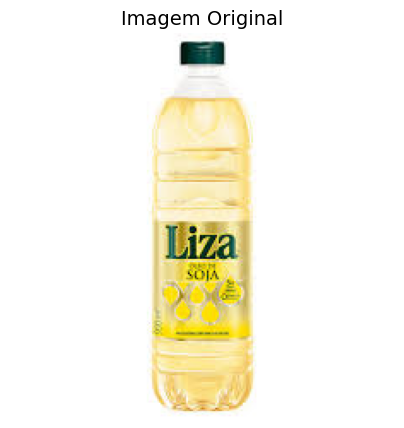

In [ ]:
# ============================================================
# IMAGEM -> MATRIZ -> EXCEL/GOOGLE SHEETS
# ============================================================
# Requisitos:
# pip install pillow numpy pandas openpyxl
#
# No Google Colab, rode:
# !pip install pillow numpy pandas openpyxl
# ============================================================

import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# ============================================================
# 1) FUNÇÃO: carregar imagem
# ============================================================

def load_image(path=None, use_colab_upload=True):

    if use_colab_upload:
        from google.colab import files
        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
        path = filename

    if path is None:
        raise ValueError("Você precisa fornecer um path ou usar use_colab_upload=True")

    img = Image.open(path).convert("RGB")  # força RGB (3 canais)
    return img


# ============================================================
# 2) FUNÇÃO: converter imagem em matriz
# ============================================================

def image_to_matrix(img):

    return np.array(img)


# ============================================================
# 3) FUNÇÃO: reduzir imagem (para não explodir a planilha)
# ============================================================

def resize_image(img, max_width=150, max_height=150):

    w, h = img.size

    scale = min(max_width / w, max_height / h, 1.0)
    new_w = int(w * scale)
    new_h = int(h * scale)

    return img.resize((new_w, new_h))


# ============================================================
# 4) FUNÇÃO: transformar pixels em tabela (cada célula = 1 pixel)
# ============================================================

def pixels_to_table(matrix):

    h, w, _ = matrix.shape

    # Cria uma matriz de strings (H x W)
    table = np.empty((h, w), dtype=object)

    for y in range(h):
        for x in range(w):
            r, g, b = matrix[y, x]
            table[y, x] = f"{r},{g},{b}"

    df = pd.DataFrame(table)
    return df


# ============================================================
# 5) FUNÇÃO: exportar para Excel e CSV
# ============================================================

def export_table(df, excel_path="pixels.xlsx", csv_path="pixels.csv"):

    df.to_excel(excel_path, index=False, header=False)
    df.to_csv(csv_path, index=False, header=False)

    print(f"✅ Excel salvo em: {excel_path}")
    print(f"✅ CSV salvo em:   {csv_path}")


# ============================================================
# 6) EXECUÇÃO PRINCIPAL
# ============================================================

if __name__ == "__main__":

    # ====== CONFIGURAÇÕES ======
    # Se estiver no Colab: coloque True
    USE_COLAB_UPLOAD = True

    # Se estiver no VSCode/local: coloque o caminho da imagem aqui
    IMAGE_PATH = "minha_imagem.png"

    # Limites (quanto maior, mais pesado)
    MAX_W = 120
    MAX_H = 120

    # ===========================

    img = load_image(path=IMAGE_PATH, use_colab_upload=USE_COLAB_UPLOAD)

    print("Imagem original:", img.size)

    # Reduz para não travar Excel/Sheets
    img_small = resize_image(img, max_width=MAX_W, max_height=MAX_H)
    print("Imagem redimensionada:", img_small.size)

    matrix = image_to_matrix(img_small)
    print("Matriz:", matrix.shape)

    df = pixels_to_table(matrix)

    export_table(df, excel_path="pixels.xlsx", csv_path="pixels.csv")
    # Exibir imagem original
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title("Imagem Original", fontsize=14)
    plt.axis('off')
    plt.show()

✅ Imagem reconstruída salva em: imagem_reconstruida.png


/tmp/ipykernel_7786/3437955509.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(matrix.astype(np.uint8), mode="RGB")


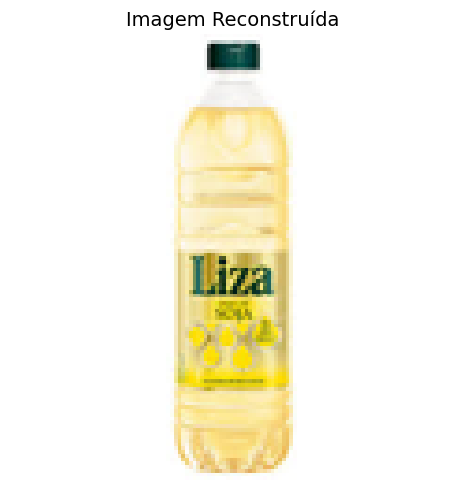

In [ ]:
# ============================================================
# 7) TABELA -> MATRIZ -> IMAGEM
# ============================================================
def table_to_matrix(df):
    """
    Reconstrói a matriz (H×W×3) a partir do DataFrame de strings 'R,G,B'.
    """
    h, w = df.shape
    matrix_rec = np.zeros((h, w, 3), dtype=np.uint8)
    for y in range(h):
        for x in range(w):
            r, g, b = map(int, str(df.iloc[y, x]).split(","))
            matrix_rec[y, x] = [r, g, b]
    return matrix_rec


def matrix_to_image(matrix):
    """Converte array NumPy de volta para objeto PIL Image."""
    return Image.fromarray(matrix.astype(np.uint8), mode="RGB")


# Lê o CSV exportado e reconstrói
df_lido = pd.read_csv("pixels.csv", header=None, dtype=str)
matrix_reconstruida = table_to_matrix(df_lido)
img_reconstruida = matrix_to_image(matrix_reconstruida)

# Salva a imagem reconstruída
img_reconstruida.save("imagem_reconstruida.png")
print("✅ Imagem reconstruída salva em: imagem_reconstruida.png")
plt.figure(figsize=(5, 5))
plt.imshow(img_reconstruida)
plt.title("Imagem Reconstruída", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 8) FUNÇÕES: Definição de Matrizes de Transformação Linear
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

def get_scaling_matrix(sx, sy):
    """Retorna a matriz de escalonamento (scaling)."""
    return np.array([[sx, 0],
                     [0, sy]])

def get_rotation_matrix(angle_deg):
    """Retorna a matriz de rotação (rotation) dado um ângulo em graus."""
    theta = np.radians(angle_deg)
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta),  np.cos(theta)]])

def get_shearing_matrix(kx, ky):
    """Retorna a matriz de cisalhamento (shearing)."""
    return np.array([[1, kx],
                     [ky, 1]])

def get_collapse_matrix():
    """Retorna uma matriz singular (det=0) que colapsa a dimensão."""
    # Exemplo: Projeção no eixo X (colapsa Y para zero)
    return np.array([[1, 0],
                     [0, 0]])

print("✅ Funções de matrizes de transformação linear definidas.")

✅ Funções de matrizes de transformação linear definidas.


In [ ]:
# ============================================================
# 9) FUNÇÃO: Aplicar Transformação Linear na Imagem
# ============================================================

def apply_linear_transformation(matrix_rgb, trans_matrix):
    """
    Aplica uma transformação linear nas coordenadas espaciais dos pixels.
    """
    h, w, c = matrix_rgb.shape

    # Criar uma nova imagem (fundo branco por padrão)
    # Calculamos o novo limite para evitar cortes excessivos, mas mantemos simples para fins didáticos
    new_img = np.ones((h * 2, w * 2, 3), dtype=np.uint8) * 255
    offset_x, offset_y = w // 2, h // 2 # Offset para centralizar visualização se necessário

    for y in range(h):
        for x in range(w):
            # Vetor de coordenada original (v)
            v = np.array([x, y])

            # Aplicação da transformação linear: v' = A * v
            v_prime = np.dot(trans_matrix, v)

            # Novas coordenadas (arredondadas para inteiros)
            new_x = int(v_prime[0]) + offset_x
            new_y = int(v_prime[1]) + offset_y

            # Verifica se está dentro dos limites da nova imagem
            if 0 <= new_x < (w * 2) and 0 <= new_y < (h * 2):
                new_img[new_y, new_x] = matrix_rgb[y, x]

    return new_img

print("✅ Função de aplicação de transformação definida.")

✅ Função de aplicação de transformação definida.


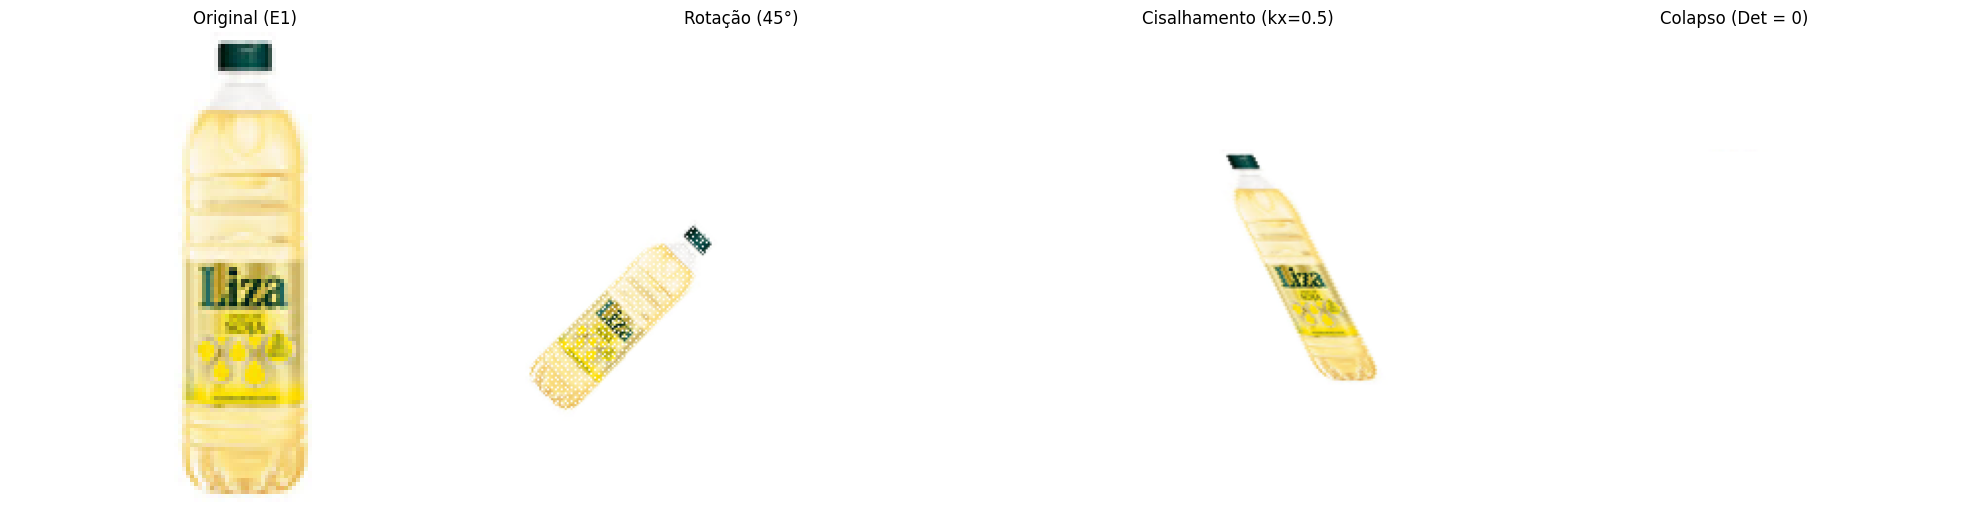

Determinante Rotação: 1.00 (Preserva dimensão)
Determinante Colapso: 0.00 (Dimensão colapsada)


In [ ]:
# ============================================================
# 10) EXECUÇÃO: Transformações e Comparação
# ============================================================

# 1. Definir matrizes de teste
matriz_rotacao = get_rotation_matrix(45)      # Rotação de 45 graus
matriz_cisalha = get_shearing_matrix(0.5, 0) # Cisalhamento horizontal
matriz_colapso = get_collapse_matrix()       # Colapso de dimensão

# 2. Aplicar as transformações
img_rotacionada = apply_linear_transformation(matrix_reconstruida, matriz_rotacao)
img_cisalhada   = apply_linear_transformation(matrix_reconstruida, matriz_cisalha)
img_colapsada   = apply_linear_transformation(matrix_reconstruida, matriz_colapso)

# 3. Visualização
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(matrix_reconstruida)
axes[0].set_title("Original (E1)")

axes[1].imshow(img_rotacionada)
axes[1].set_title("Rotação (45°)")

axes[2].imshow(img_cisalhada)
axes[2].set_title("Cisalhamento (kx=0.5)")

axes[3].imshow(img_colapsada)
axes[3].set_title("Colapso (Det = 0)")

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

# Verificação do determinante para análise conceitual
print(f"Determinante Rotação: {np.linalg.det(matriz_rotacao):.2f} (Preserva dimensão)")
print(f"Determinante Colapso: {np.linalg.det(matriz_colapso):.2f} (Dimensão colapsada)")

### 11) Relatório Final: Análise de Transformações Lineares em Imagens

Este relatório sintetiza os processos de Álgebra Linear aplicados à manipulação de imagens digitais, onde cada pixel é tratado como um vetor de coordenadas $(x, y)$ no espaço $\mathbb{R}^2$.

#### 1. Rotação ($Det = 1$)
*   **Processo:** Multiplicamos o vetor de cada pixel por uma matriz de rotação $R_\theta$. Esta matriz é ortogonal, o que garante a preservação de comprimentos e ângulos.
*   **Análise:** Como o determinante é exatamente 1, a área total da imagem é preservada. Matematicamente, a transformação é um isomorfismo (invertível), permitindo que a imagem original seja recuperada sem perda de informação.

#### 2. Cisalhamento (Shearing)
*   **Processo:** Introduzimos um deslocamento lateral proporcional a uma das coordenadas (ex: $x' = x + ky$).
*   **Análise:** Embora a imagem pareça "inclinada" ou distorcida, o determinante desta matriz também é 1. Isso significa que, embora a forma mude, a área total ocupada pelos pixels permanece constante. É uma transformação linear que preserva a continuidade, mas altera a ortogonalidade dos eixos.

#### 3. Colapso de Dimensão ($Det = 0$)
*   **Processo:** Utilizamos uma matriz singular (não invertível). No experimento, projetamos todos os pontos $(x, y)$ para o eixo $X$, definindo $y = 0$.
*   **Análise:** O determinante zero indica que o mapeamento reduz a dimensão do espaço (de $\mathbb{R}^2$ para $\mathbb{R}^1$). Visualmente, a imagem transforma-se em uma linha. Este processo é irreversível; a informação da altura original foi permanentemente perdida, exemplificando o conceito de núcleo (kernel) não trivial de uma transformação linear.

#### 4. Conclusão Técnica
A manipulação de imagens via matrizes demonstra de forma prática como propriedades abstratas da Álgebra Linear (determinantes, invertibilidade e dimensão) ditam o que acontece com a informação visual. Transformações com $Det \neq 0$ apenas reorganizam a informação, enquanto transformações com $Det = 0$ comprimem e destroem dados.